#### Цель
Научиться решать прикладную задачу бинарной классификации на смешанных табличных данных: по поведению посетителя интернет-магазина предсказать, завершится ли текущая сессия покупкой (Revenue).
#### Данные
Используй Online Shoppers Purchasing Intention Dataset от UCI: 12 330 сессий, 17 признаков и бинарная цель Revenue. Покупкой заканчиваются только 1 908 сессий (около 15,5%), поэтому одной Accuracy для выбора модели недостаточно.  
В частях I–II достаточно одного или нескольких Jupyter-ноутбуков (.ipynb). Отдельный проект понадобится только в части III. Все три части можно вести в одном репозитории, сохраняя результат каждой на отдельной ветке: clf/online_shoppers/part_1, clf/online_shoppers/part_2, clf/online_shoppers/part_3. Сырые данные не коммить в репозиторий: скачай их по официальной ссылке или загружай программно.
#### Задание
1. Постановка: зафиксируй момент принятия решения — модель должна оценивать вероятность покупки во время визита, чтобы маркетинг мог показать посетителю дополнительный стимул. Цель — Revenue.
2. EDA: изучи размеры таблицы, типы и диапазоны признаков, пропуски, дубликаты и распределение классов. Отдельно покажи числовые и категориальные признаки и объясни, почему дисбаланс делает Accuracy недостаточной.
3. Разделение и подготовка: сделай стратифицированный train/test split с фиксированным random_state. Собери Pipeline / ColumnTransformer: все обучаемые преобразования, включая заполнение пропусков, кодирование категорий и масштабирование для логистической регрессии, настраиваются только на train.
4. Базовые модели: обучи логистическую регрессию и решающее дерево. Сведи результаты на test в таблицу: PR-AUC, ROC AUC, precision, recall, F1 и confusion matrix.
5. Выбор: выбери основную метрику PR-AUC и объясни выбор финальной модели не только числом, но и компромиссом между тем, скольких потенциальных покупателей она находит и скольким посетителям будет показана лишняя акция.
6. PageValues и утечка: в финальный real-time набор признаков PageValues не включай. Объясни, что значение формируется из ценности страниц и достижения целевой страницы в сессии, поэтому в момент показа стимула может зависеть от информации, появляющейся позднее, и быть прокси таргета. Можно выполнить отдельное диагностическое сравнение на validation/OOF-предсказаниях с PageValues и без него, но не выбирай по версии с этим признаком финальную модель и не используй её для честной test-оценки.
#### Другое
Построй PR-кривую и ROC-кривую для логистической регрессии и дерева на одном графике.
Зафиксируй в выводах, какие признаки доступны в момент скоринга, а какие появляются только после дальнейших действий пользователя.

#### 1. Библиотеки и модули

In [1]:
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import hashlib
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix, precision_recall_curve,
    roc_curve, ConfusionMatrixDisplay,
)
from sklearn.exceptions import ConvergenceWarning

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
# Не скрываем несходимость: при её возникновении вычисления останавливаются.
warnings.filterwarnings('error', category=ConvergenceWarning)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})
display(pd.Series({'Python': platform.python_version(), 'numpy': np.__version__,
                   'pandas': pd.__version__, 'scikit-learn': sklearn.__version__,
                   'matplotlib': matplotlib.__version__}, name='Версия').to_frame())

,Версия
Python,3.12.2
numpy,2.5.2
pandas,3.0.5
scikit-learn,1.9.0
matplotlib,3.11.1


#### 2. Загрузка и первичная проверка  
Сначала проверяем схему, пропуски, дубликаты и баланс классов всей исходной таблицы. Подробный анализ связей признаков с target выполняем только на train.

In [4]:
DATA_PATH = Path('data/online_shoppers_intention/online_shoppers_intention.csv')
UCI_ZIP_URL = (
    'https://archive.ics.uci.edu/static/public/468/'
    'online+shoppers+purchasing+intention+dataset.zip'
)
candidates = [DATA_PATH, Path('..') / DATA_PATH,
              Path('online_shoppers_intention.csv'),
              Path('online_shoppers_intention(1).csv'),
              Path('upload/online_shoppers_intention(1).csv')]
local_path = next((p for p in candidates if p.is_file()), None)
if local_path is None:
    try:
        with urlopen(UCI_ZIP_URL, timeout=60) as response:
            archive_bytes = response.read()
        with ZipFile(BytesIO(archive_bytes)) as archive:
            member = next(n for n in archive.namelist()
                          if Path(n).name == 'online_shoppers_intention.csv')
            csv_bytes = archive.read(member)
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        DATA_PATH.write_bytes(csv_bytes)
        local_path = DATA_PATH
    except Exception as exc:
        raise RuntimeError(f'Не удалось загрузить UCI. Поместите CSV в {DATA_PATH}.') from exc

raw = pd.read_csv(local_path)
print(f'Источник: {local_path.as_posix()}')
print('SHA-256:', hashlib.sha256(local_path.read_bytes()).hexdigest())
print(f'Размер: {raw.shape[0]:,} строк x {raw.shape[1]} столбцов')
display(raw.head(10))

Источник: data/online_shoppers_intention/online_shoppers_intention.csv
SHA-256: b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9
Размер: 12,330 строк x 18 столбцов


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0000,0,0.0000,19,154.2167,0.0158,0.0246,0.0000,0.0000,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.4000,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0000,0,0.0000,0,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0000,0,0.0000,2,37.0000,0.0000,0.1000,0.0000,0.8000,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0000,0,0.0000,3,738.0000,0.0000,0.0222,0.0000,0.4000,Feb,2,4,1,2,Returning_Visitor,False,False


In [5]:
# Смысл признака и тип.
numeric_features = [
    'Administrative', 'Administrative_Duration', 'Informational',
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
]
categorical_features = [
    'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType',
    'VisitorType', 'Weekend',
]
feature_columns = numeric_features + categorical_features
expected_columns = set(feature_columns + ['PageValues', 'Revenue'])
assert set(raw.columns) == expected_columns, 'Неожиданная схема CSV'
assert not raw['Revenue'].isna().any(), 'В целевой переменной есть пропуски'
assert set(raw['Revenue'].unique()) <= {False, True, 0, 1}, 'Revenue должна быть бинарной'
assert np.isfinite(raw.select_dtypes(include='number').dropna().to_numpy()).all()

schema = pd.DataFrame({
    'dtype': raw.dtypes.astype(str), 'Пропуски': raw.isna().sum(),
    'Уникальных': raw.nunique(),
})
schema['Роль'] = ['цель' if c == 'Revenue' else 'исключён (PageValues)'
                  if c == 'PageValues' else 'числовой' if c in numeric_features
                  else 'категориальный' for c in schema.index]
display(schema)
class_counts = raw['Revenue'].astype(int).value_counts().sort_index()
display(pd.DataFrame({'Сессий': class_counts, 'Доля': class_counts / len(raw)}))
print('Полных дубликатов:', raw.duplicated().sum())
print('Пропусков во всей таблице:', int(raw.isna().sum().sum()))
print(f'Accuracy константы «нет покупки»: {(raw.Revenue == 0).mean():.2%}')

,dtype,Пропуски,Уникальных,Роль
Administrative,int64,0,27,числовой
Administrative_Duration,float64,0,3335,числовой
Informational,int64,0,17,числовой
Informational_Duration,float64,0,1258,числовой
ProductRelated,int64,0,311,числовой
ProductRelated_Duration,float64,0,9551,числовой
BounceRates,float64,0,1872,числовой
ExitRates,float64,0,4777,числовой
PageValues,float64,0,2704,исключён (PageValues)
SpecialDay,float64,0,6,числовой


,Сессий,Доля
Revenue,,
0,10422,0.8453
1,1908,0.1547


Полных дубликатов: 125
Пропусков во всей таблице: 0
Accuracy константы «нет покупки»: 84.53%


Коды ОС, браузера, региона и источника трафика — неинтересные категории, ведь разность между кодами не имеет количественного смысла. Weekend также кодируем как категорию. SpecialDay оставляем числовым показателем близости к специальному дню. Итого: исходно 10 числовых и 7 категориальных признаков; после исключения PageValues будет 9 + 7 = 16.

Постоянное предсказание «нет покупки» даёт Accuracy около 84,5%, но recall покупателей равен нулю. Поэтому высокая Accuracy сама по себе НЕ означает полезность для маркетинга.

Полностью совпадающие записи могут быть как повторной выгрузкой, так и разными похожими визитами, ведь дентификаторов для проверки нет. Мое решение: удалить точные повторы до split, чтобы копии не попали в train и test. Это меняет объект оценки: метрики далее относятся к таблице без повторов, а не к исходному потоку всех сессий. Пропуски заполнять сейчас не будем: imputer обучается внутри Pipeline.

In [6]:
data = raw.drop_duplicates().reset_index(drop=True)
print(f'После удаления повторов: {len(data):,} сессий; покупок: {int(data.Revenue.sum()):,}; '
      f'доля: {data.Revenue.mean():.2%}')
X = data[feature_columns].copy()
y = data['Revenue'].astype(int)
# Это фиксированное преобразование типа, без обучения на статистиках данных.
X['Weekend'] = X['Weekend'].astype(int)
assert 'PageValues' not in X.columns and 'Revenue' not in X.columns
assert not X.duplicated().any(), 'Остались одинаковые наборы признаков: нужен групповой split'

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE,
)
assert set(X_train.index).isdisjoint(X_test.index)
split_summary = pd.DataFrame({
    'Сессий': [len(y_train), len(y_test)],
    'Покупок': [int(y_train.sum()), int(y_test.sum())],
    'Доля покупок': [y_train.mean(), y_test.mean()],
}, index=['train', 'test'])
display(split_summary)

После удаления повторов: 12,205 сессий; покупок: 1,908; доля: 15.63%


,Сессий,Покупок,Доля покупок
train,9764,1526,0.1563
test,2441,382,0.1565


#### 3. EDA на train
Далее test не используем до итогового раздела. Изучаем диапазоны, асимметрию и частоты категорий. ВАЖНО - длинный правый хвост длительности не означает ошибку автоматически: без внешних оснований не удаляем такие сессии и не подбираем границы по test.

,count,mean,std,min,1%,25%,50%,75%,99%,max
Administrative,9764.0000,2.3427,3.3493,0.0000,0.0000,0.0000,1.0000,4.0000,14.0000,27.0000
Administrative_Duration,9764.0000,82.2199,179.5024,0.0000,0.0000,0.0000,9.0000,94.7250,845.5329,3398.7500
Informational,9764.0000,0.5103,1.2827,0.0000,0.0000,0.0000,0.0000,0.0000,6.0000,24.0000
Informational_Duration,9764.0000,34.9506,143.8283,0.0000,0.0000,0.0000,0.0000,0.0000,746.8450,2549.3750
ProductRelated,9764.0000,32.1018,44.8173,0.0000,1.0000,8.0000,18.0000,39.0000,221.0000,705.0000
ProductRelated_Duration,9764.0000,1207.2647,1926.3892,0.0000,0.0000,193.4667,617.0000,1483.6500,8690.3201,63973.5222
BounceRates,9764.0000,0.0203,0.0452,0.0000,0.0000,0.0000,0.0029,0.0167,0.2000,0.2000
ExitRates,9764.0000,0.0415,0.0461,0.0000,0.0013,0.0143,0.0250,0.0492,0.2000,0.2000
SpecialDay,9764.0000,0.0624,0.2000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000


,Категории на train,Число категорий
Month,"Aug, Dec, Feb, Jul, June, Mar, May, Nov, Oct, Sep",10
OperatingSystems,"1, 2, 3, 4, 5, 6, 7, 8",8
Browser,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13",13
Region,"1, 2, 3, 4, 5, 6, 7, 8, 9",9
TrafficType,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15,...",19
VisitorType,"New_Visitor, Other, Returning_Visitor",3
Weekend,"0, 1",2


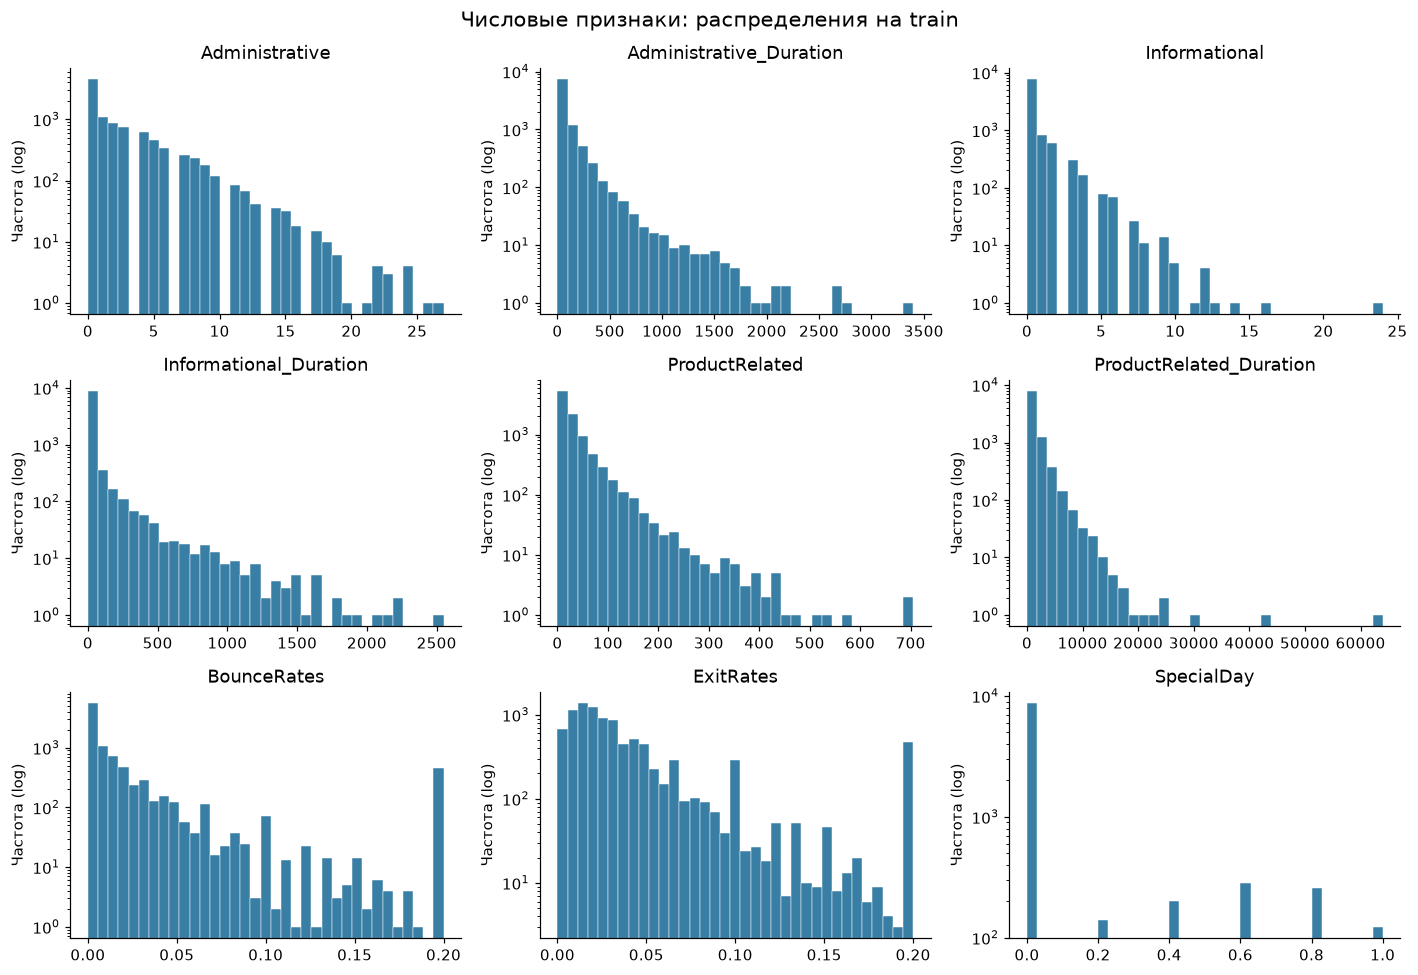

In [7]:
display(X_train[numeric_features].describe(percentiles=[.01, .25, .5, .75, .99]).T)
display(pd.DataFrame({
    'Категории на train': {c: ', '.join(map(str, sorted(X_train[c].dropna().unique())))
                          for c in categorical_features},
    'Число категорий': X_train[categorical_features].nunique(),
}))
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.flat, numeric_features):
    ax.hist(X_train[col].dropna(), bins=35, color='#397fa5', edgecolor='white', linewidth=.3)
    ax.set_title(col)
    ax.set_yscale('log')
    ax.set_ylabel('Частота (log)')
fig.suptitle('Числовые признаки: распределения на train', fontsize=14)
fig.tight_layout()
plt.show()

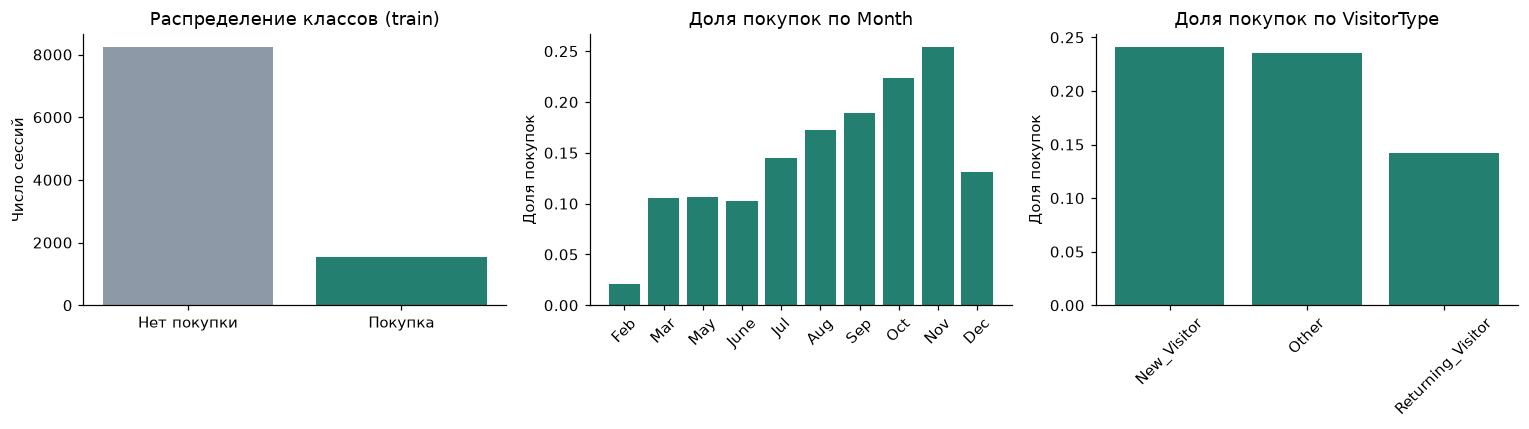

Month


,Сессий,Доля_покупок
Month,,
Aug,360,0.1722
Dec,1363,0.1313
Feb,144,0.0208
Jul,353,0.1445
June,225,0.1022
Mar,1500,0.1060
May,2674,0.1070
Nov,2358,0.2540
Oct,433,0.2240


OperatingSystems


,Сессий,Доля_покупок
OperatingSystems,,
1,2010,0.1468
2,5237,0.1762
3,2048,0.1069
4,383,0.1828
5,5,0.2000
6,12,0.1667
7,6,0.1667
8,63,0.2381


Browser


...

,Сессий,Доля_покупок
TrafficType,,
1,1944,0.1080
2,3111,0.2150
3,1611,0.0912
4,858,0.1515
5,197,0.2234
6,367,0.1199
7,32,0.3438
8,267,0.2772
9,36,0.1111


VisitorType


,Сессий,Доля_покупок
VisitorType,,
New_Visitor,1349,0.2409
Other,68,0.2353
Returning_Visitor,8347,0.1420


Weekend


,Сессий,Доля_покупок
Weekend,,
0,7480,0.1507
1,2284,0.1747


In [8]:
train_eda = X_train.assign(Revenue=y_train)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
counts = y_train.value_counts().sort_index()
axes[0].bar(['Нет покупки', 'Покупка'], counts, color=['#8d99a6', '#237f70'])
axes[0].set_title('Распределение классов (train)')
axes[0].set_ylabel('Число сессий')
for ax, col in zip(axes[1:], ['Month', 'VisitorType']):
    group = train_eda.groupby(col)['Revenue'].agg(['size', 'mean'])
    if col == 'Month':
        month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        group = group.reindex([m for m in month_order if m in group.index])
    ax.bar(group.index, group['mean'], color='#237f70')
    ax.set_title(f'Доля покупок по {col}')
    ax.set_ylabel('Доля покупок')
    ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()
for col in categorical_features:
    print(col)
    display(train_eda.groupby(col)['Revenue'].agg(Сессий='size', Доля_покупок='mean'))

Распределения длительностей и числа страниц асимметричны, много нулевых значений. Месяцы неравномерно; для редких категорий доли покупок нестабильны. Связь месяца или типа посетителя с покупкой — думаю, что не эффект акции. В этой базовой версии оставляем исходные числовые значения и используем масштабирование для логистической регрессии. Преобразование log1p можно исследовать позже на CV.  
Случайный split оценивает перенос на похожие сессии этой выборки. Он не проверяет перенос на следующий год или новый рекламный канал; полноценного времени сессии здесь нет.

#### 4. Метрики и протокол сравнения
Положительный класс — покупка. Для решения «показать акцию» задаём порог $t$:
$\hat y=1$ при $\hat p(Revenue=1)\geq t$.  Precision, Recall, F_1 
Фиксируем две базовые конфигурации → получаем 5-fold OOF-прогнозы только на train → выбираем модель по среднему AP фолдов → выбираем порог по OOF → обучаем на всём train → один раз оцениваем обе модели на test. OOF означает, что каждую строку предсказывает модель, которая эту строку не видела при обучении.
Выбираем порог с максимальным OOF.

In [9]:
def make_pipeline(model_name, include_pagevalues=False):
    """Новый независимый Pipeline для каждой модели и каждого фолда."""
    num_cols = numeric_features + (['PageValues'] if include_pagevalues else [])
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if model_name == 'LogisticRegression':
        num_steps.append(('scaler', StandardScaler()))
        model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=3000,
                                   random_state=RANDOM_STATE)
    elif model_name == 'DecisionTree':
        model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50,
                                       random_state=RANDOM_STATE)
    else:
        raise ValueError(f'Неизвестная модель: {model_name}')

    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    preprocessor = ColumnTransformer([
        ('num', Pipeline(num_steps), num_cols),
        ('cat', cat_pipeline, categorical_features),
    ], remainder='drop')
    return Pipeline([('preprocessor', preprocessor), ('model', model)])

model_names = ['LogisticRegression', 'DecisionTree']
models = {name: make_pipeline(name) for name in model_names}
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds = list(cv.split(X_train, y_train))

Числа заполняются медианой, категории — наиболее частым значением. Логистическая регрессия получает стандартизованные числовые признаки; дереву масштабирование не требуется. One-hot кодирование не задаёт искусственного порядка категориям. handle_unknown='ignore' позволяет обработать категорию, которой не было при обучении.  
Импутация, scaler и encoder обучаются внутри каждого train-фолда. C=1 задаёт обычную L2-регуляризацию логистической регрессии; ограничения глубины и размера листа сдерживают переобучение дерева. Параметры заданы заранее, поиска по test нет. class_weight=None оставляем по умолчанию: дисбаланс сам по себе не требует весов или SMOTE. Компромисс обнаружения покупателей изучаем изменением порога. predict_proba здесь — оценка вероятности, её калибровка отдельной проверкой не подтверждалась.

In [10]:
def collect_oof(pipeline, features, target, splits):
    """Обучает все преобразования на train-фолде и возвращает OOF-score и метрики."""
    oof = np.full(len(target), np.nan)
    rows = []
    for fold, (fit_idx, valid_idx) in enumerate(splits, start=1):
        fitted = clone(pipeline).fit(features.iloc[fit_idx], target.iloc[fit_idx])
        p_valid = fitted.predict_proba(features.iloc[valid_idx])[:, 1]
        p_fit = fitted.predict_proba(features.iloc[fit_idx])[:, 1]
        oof[valid_idx] = p_valid
        rows.append({'Fold': fold,
                     'AP_train': average_precision_score(target.iloc[fit_idx], p_fit),
                     'AP_valid': average_precision_score(target.iloc[valid_idx], p_valid),
                     'ROC_AUC_valid': roc_auc_score(target.iloc[valid_idx], p_valid)})
    assert np.isfinite(oof).all()
    return oof, pd.DataFrame(rows)

oof_predictions, cv_details = {}, {}
for name, pipeline in models.items():
    oof_predictions[name], cv_details[name] = collect_oof(pipeline, X_train, y_train, folds)

cv_summary = pd.DataFrame({name: {
    'AP_train_mean': details.AP_train.mean(),
    'AP_CV_mean': details.AP_valid.mean(),
    'AP_CV_std': details.AP_valid.std(ddof=1),
    'AP_OOF': average_precision_score(y_train, oof_predictions[name]),
    'ROC_AUC_OOF': roc_auc_score(y_train, oof_predictions[name]),
} for name, details in cv_details.items()}).T
display(pd.concat(cv_details, names=['Модель', 'Строка']).reset_index(level='Строка', drop=True))
display(cv_summary) # type: ignore
# Среднее AP фолдов и AP объединённых OOF могут различаться.
selected_name = cv_summary['AP_CV_mean'].idxmax()
print('Выбранная по CV модель:', selected_name)

,Fold,AP_train,AP_valid,ROC_AUC_valid
Модель,,,,
LogisticRegression,1,0.3475,0.3369,0.7476
LogisticRegression,2,0.3600,0.2791,0.7074
LogisticRegression,3,0.3404,0.3605,0.7724
LogisticRegression,4,0.3477,0.3269,0.7309
LogisticRegression,5,0.3477,0.3356,0.7586
DecisionTree,1,0.3637,0.3324,0.7533
DecisionTree,2,0.3770,0.2921,0.7136
DecisionTree,3,0.3537,0.3444,0.7558
DecisionTree,4,0.3570,0.3334,0.7333


,AP_train_mean,AP_CV_mean,AP_CV_std,AP_OOF,ROC_AUC_OOF
LogisticRegression,0.3487,0.3278,0.0299,0.3211,0.7433
DecisionTree,0.3645,0.3252,0.0199,0.3303,0.7395


Выбранная по CV модель: LogisticRegression


Средние CV AP очень близки у логистической регрессии и дерева. Разница меньше разброса по фолдам; устойчивое превосходство не установлено. Выбираем логистическую регрессию. Объединённый OOF AP немного выше у дерева.

In [11]:
def threshold_metrics(y_true, probability, threshold):
    predicted = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {'threshold': float(threshold),
            'precision': precision_score(y_true, predicted, zero_division=0),
            'recall': recall_score(y_true, predicted, zero_division=0),
            'F1': f1_score(y_true, predicted, zero_division=0),
            'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
            'Показов': int(tp + fp), 'Доля показов': float(predicted.mean())}

thresholds, threshold_rows = {}, []
for name, probability in oof_predictions.items():
    precision, recall, candidate_thresholds = precision_recall_curve(y_train, probability)
    # Последняя точка PR-кривой не имеет порога.
    f1_values = np.divide(2 * precision[:-1] * recall[:-1], precision[:-1] + recall[:-1],
                          out=np.zeros_like(candidate_thresholds),
                          where=(precision[:-1] + recall[:-1]) > 0)
    # При равном F1 выбираем больший порог: не увеличиваем число показов без выигрыша F1.
    best_indices = np.flatnonzero(np.isclose(f1_values, f1_values.max(), rtol=0, atol=1e-12))
    thresholds[name] = float(candidate_thresholds[best_indices[-1]])
    for t in sorted(set([0.10, 0.20, 0.30, 0.50, thresholds[name]])):
        threshold_rows.append({'Модель': name, 'Выбран': t == thresholds[name],
                               **threshold_metrics(y_train, probability, t)})
oof_threshold_table = pd.DataFrame(threshold_rows)
display(oof_threshold_table)
selected_threshold = thresholds[selected_name]
print(f'Зафиксировано ДО test: {selected_name}, порог {selected_threshold:.6f}')

,Модель,Выбран,threshold,precision,recall,F1,TN,FP,FN,TP,Показов,Доля показов
0,LogisticRegression,False,0.1000,0.2279,0.8879,0.3627,3647,4591,171,1355,5946,0.6090
1,LogisticRegression,True,0.1757,0.2768,0.6710,0.3919,5562,2676,502,1024,3700,0.3789
2,LogisticRegression,False,0.2000,0.2890,0.5845,0.3868,6044,2194,634,892,3086,0.3161
3,LogisticRegression,False,0.3000,0.3545,0.3067,0.3289,7386,852,1058,468,1320,0.1352
4,LogisticRegression,False,0.5000,0.4757,0.0321,0.0602,8184,54,1477,49,103,0.0105
5,DecisionTree,False,0.1000,0.2236,0.8814,0.3567,3568,4670,181,1345,6015,0.6160
6,DecisionTree,False,0.2000,0.2915,0.5773,0.3874,6097,2141,645,881,3022,0.3095
7,DecisionTree,True,0.2303,0.3210,0.5111,0.3943,6588,1650,746,780,2430,0.2489
8,DecisionTree,False,0.3000,0.3828,0.2857,0.3272,7535,703,1090,436,1139,0.1167
9,DecisionTree,False,0.5000,0.4783,0.0649,0.1143,8130,108,1427,99,207,0.0212


Зафиксировано ДО test: LogisticRegression, порог 0.175720


In [18]:
chosen_oof = threshold_metrics(y_train, oof_predictions[selected_name], selected_threshold)
other_name = next(name for name in model_names if name != selected_name)
other_oof = threshold_metrics(y_train, oof_predictions[other_name], thresholds[other_name])
display(Markdown(
    f"**Выбор до test:** {selected_name}: средний CV AP = "
    f"{cv_summary.loc[selected_name, 'AP_CV_mean']:.3f}, у {other_name} — "
    f"{cv_summary.loc[other_name, 'AP_CV_mean']:.3f}. "
    f"При выбранном OOF-пороге recall = {chosen_oof['recall']:.1%}, "
    f"precision = {chosen_oof['precision']:.1%}; модель отмечает "
    f"{chosen_oof['TP']} покупателей и {chosen_oof['FP']} непокупателей. "
    f"У второй модели при её OOF-пороге: {other_oof['TP']} и {other_oof['FP']} соответственно. "
    "Сравнивать нужно и найденных покупателей, и нагрузку от ложных показов. "
    "Если выбранная по AP модель не укладывается в план маркетинга, рабочий порог следует пересмотреть "
    "на train/CV с заранее заданным ограничением. В этой задаче правило — максимум OOF F1. "
    "Стандартное отклонение по пяти фолдам показывает разброс, но не является доверительным интервалом."
))

**Выбор до test:** LogisticRegression: средний CV AP = 0.328, у DecisionTree — 0.325. При выбранном OOF-пороге recall = 67.1%, precision = 27.7%; модель отмечает 1024 покупателей и 2676 непокупателей. У второй модели при её OOF-пороге: 780 и 1650 соответственно. Сравнивать нужно и найденных покупателей, и нагрузку от ложных показов. Если выбранная по AP модель не укладывается в план маркетинга, рабочий порог следует пересмотреть на train/CV с заранее заданным ограничением. В этой задаче правило — максимум OOF F1. Стандартное отклонение по пяти фолдам показывает разброс, но не является доверительным интервалом.

#### 5. Диагностика PageValues — только на train / OOF
На тех же фолдах и с теми же параметрами сравниваем модели с PageValues и без него. Изменение AP покажет силу признака, но само по себе не докажет утечку: это устанавливается по времени и происхождению данных. Выбор основной модели и пороги уже зафиксированы. Диагностическая версия не получает test и не участвует в выборе.

In [19]:
X_train_diagnostic = X_train.assign(PageValues=data.loc[X_train.index, 'PageValues'])
diagnostic_rows = []
for name in model_names:
    diagnostic_oof, _ = collect_oof(
        make_pipeline(name, include_pagevalues=True), X_train_diagnostic, y_train, folds,
    )
    ap_without = average_precision_score(y_train, oof_predictions[name])
    ap_with = average_precision_score(y_train, diagnostic_oof)
    diagnostic_rows.append({'Модель': name, 'AP_OOF без PageValues': ap_without,
                            'AP_OOF с PageValues': ap_with, 'Разница AP': ap_with - ap_without})
diagnostic_table = pd.DataFrame(diagnostic_rows).set_index('Модель')
display(diagnostic_table)
assert 'PageValues' not in X_train and 'PageValues' not in X_test

,AP_OOF без PageValues,AP_OOF с PageValues,Разница AP
Модель,,,
LogisticRegression,0.3211,0.6347,0.3136
DecisionTree,0.3303,0.7137,0.3834


#### 6. Итоговая test-оценка
Обучаем обе основные модели на всём train. Показываем единую таблицу при пороге 0,5, а затем при индивидуальных порогах, выбранных только по OOF. AP и ROC AUC рассчитываем по вероятностям, precision/recall/F1 и confusion matrix — по бинарным решениям. Матрица имеет порядок [[TN, FP], [FN, TP]]; строки — истинный класс, столбцы — прогноз. Модель не перевыбирается по этой таблице.

In [ ]:
fitted_models, test_probabilities = {}, {}
for name, pipeline in models.items():
    fitted_models[name] = clone(pipeline).fit(X_train, y_train)
    test_probabilities[name] = fitted_models[name].predict_proba(X_test)[:, 1]

dummy = DummyClassifier(strategy='prior').fit(X_train, y_train)
dummy_probability = dummy.predict_proba(X_test)[:, 1]
all_test_probabilities = {'Dummy (prior)': dummy_probability, **test_probabilities}

def evaluation_row(name, probability, threshold):
    result = threshold_metrics(y_test, probability, threshold)
    matrix = [[result['TN'], result['FP']], [result['FN'], result['TP']]]
    return {'Модель': name,
            'PR-AUC (AP)': average_precision_score(y_test, probability),
            'ROC AUC': roc_auc_score(y_test, probability),
            **result,
            'Accuracy': accuracy_score(y_test, probability >= threshold),
            'Confusion matrix': matrix}

test_default = pd.DataFrame([
    evaluation_row(name, probability, 0.5)
    for name, probability in all_test_probabilities.items()
]).set_index('Модель')
test_selected = pd.DataFrame([
    evaluation_row(name, probability, thresholds[name])
    for name, probability in test_probabilities.items()
]).set_index('Модель')
print('Test: общий порог 0.5')
display(test_default)
print('Test: пороги зафиксированы по OOF')
display(test_selected)
assert np.isclose(test_default.loc['Dummy (prior)', 'PR-AUC (AP)'], y_test.mean())
#for row in test_selected.itertuples():
#    assert row.TN + row.FP + row.FN + row.TP == len(y_test)

Test: общий порог 0.5


,PR-AUC (AP),ROC AUC,threshold,precision,recall,F1,TN,FP,FN,TP,Показов,Доля показов,Accuracy,Confusion matrix
Модель,,,,,,,,,,,,,,
Dummy (prior),0.1565,0.5000,0.5000,0.0000,0.0000,0.0000,2059,0,382,0,0,0.0000,0.8435,"[[2059, 0], [382, 0]]"
LogisticRegression,0.3325,0.7537,0.5000,0.5000,0.0393,0.0728,2044,15,367,15,30,0.0123,0.8435,"[[2044, 15], [367, 15]]"
DecisionTree,0.3086,0.7349,0.5000,0.4762,0.0785,0.1348,2026,33,352,30,63,0.0258,0.8423,"[[2026, 33], [352, 30]]"


Test: пороги зафиксированы по OOF


,PR-AUC (AP),ROC AUC,threshold,precision,recall,F1,TN,FP,FN,TP,Показов,Доля показов,Accuracy,Confusion matrix
Модель,,,,,,,,,,,,,,
LogisticRegression,0.3325,0.7537,0.1757,0.2881,0.7120,0.4103,1387,672,110,272,944,0.3867,0.6796,"[[1387, 672], [110, 272]]"
DecisionTree,0.3086,0.7349,0.2303,0.3048,0.5026,0.3794,1621,438,190,192,630,0.2581,0.7427,"[[1621, 438], [190, 192]]"


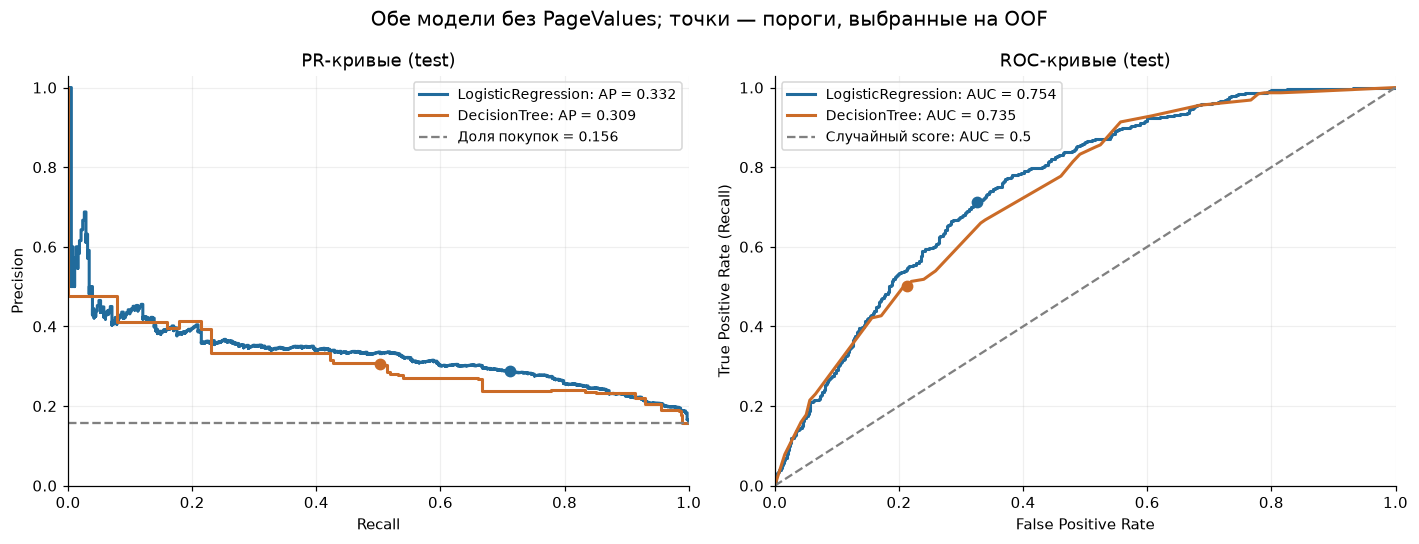

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'LogisticRegression': '#216b9c', 'DecisionTree': '#cb6b27'}
for name, probability in test_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, probability)
    fpr, tpr, _ = roc_curve(y_test, probability)
    ap = average_precision_score(y_test, probability)
    roc_auc = roc_auc_score(y_test, probability)
    axes[0].step(recall, precision, where='post', color=colors[name],
                 label=f'{name}: AP = {ap:.3f}', linewidth=2)
    axes[1].plot(fpr, tpr, color=colors[name], label=f'{name}: AUC = {roc_auc:.3f}', linewidth=2)
    result = threshold_metrics(y_test, probability, thresholds[name])
    axes[0].scatter(result['recall'], result['precision'], color=colors[name], s=45, zorder=5)
    axes[1].scatter(result['FP'] / (result['FP'] + result['TN']), result['recall'],
                    color=colors[name], s=45, zorder=5)
axes[0].axhline(y_test.mean(), color='gray', linestyle='--',
               label=f'Доля покупок = {y_test.mean():.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Случайный score: AUC = 0.5')
axes[0].set(xlabel='Recall', ylabel='Precision', title='PR-кривые (test)')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate (Recall)', title='ROC-кривые (test)')
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.03)
    ax.grid(alpha=.2)
    ax.legend(loc='best', fontsize=9)
fig.suptitle('Обе модели без PageValues; точки — пороги, выбранные на OOF', fontsize=13)
fig.tight_layout()
plt.show()

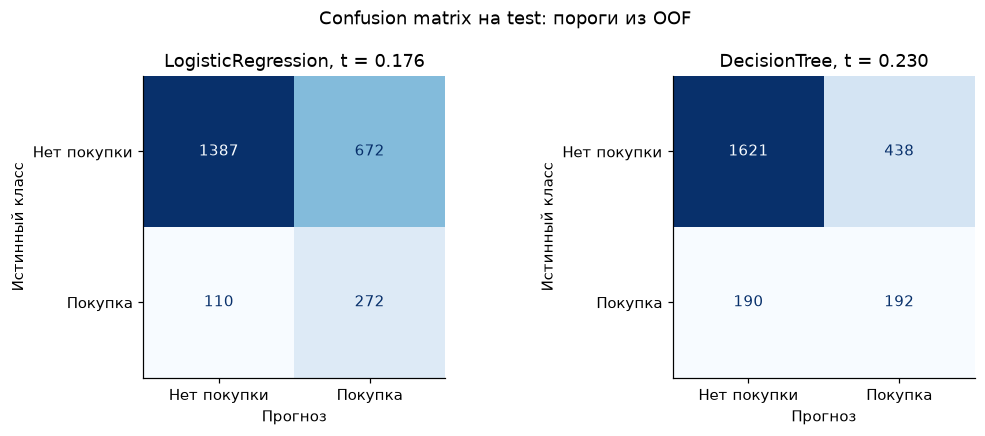

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, model_names):
    prediction = (test_probabilities[name] >= thresholds[name]).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, prediction, labels=[0, 1], display_labels=['Нет покупки', 'Покупка'],
        ax=ax, colorbar=False, cmap='Blues', values_format='d',
    )
    ax.set_title(f'{name}, t = {thresholds[name]:.3f}')
    ax.set_xlabel('Прогноз')
    ax.set_ylabel('Истинный класс')
fig.suptitle('Confusion matrix на test: пороги из OOF')
fig.tight_layout()
plt.show()

#### 7. Выводы и маркетинг-объяснение
Модель ранжирует вероятность покупки в наблюдаемом режиме. Понижение порога обычно расширяет охват и повышает recall, но добавляет ложные показы; precision при этом не обязана изменяться строго монотонно.

Финальная модель — LogisticRegression, выбрана до test по среднему CV AP. Рабочий порог: 0.1757.

* Test PR-AUC (AP): 0.332, ROC AUC: 0.754.
* Precision: 28.8%, recall: 71.2%, F1: 0.410.
* Из 382 покупателей найдено 272, пропущено 110.
* Акция была бы показана 944 посетителям, включая 672 непокупателей по наблюдаемой метке. Доля таких ложных показов: 71.2%.
* При пороге 0,5 у той же модели: TP = 15, FP = 15, recall = 3.9%. Выбранный порог меняет охват и число ложных показов.
* На 1 000 сессий с таким же составом это примерно 111 найденных покупателей и 275 ложных показов. Это пересчёт test-частот, не прогноз эффекта кампании маркетинга.
PR-AUC выбрана основной: она связывает охват редкого положительного класса с точностью отбора. ROC AUC служит дополнительной оценкой ранжирования. Понятно, что высокая Accuracy константной модели не помогает находить покупателей.